In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
dane00=pd.read_csv('pokemon_data.csv')
#..Preparing data - choosing right columns and grouping by type
stats00=['type1','height','weight','hp','attack','defense','sp_atk','sp_def','speed']
dane01=dane00[stats00]
dane01.columns=['Type','Height','Weight','HP','Attack','Defense','Attack Speed','Defense Speed','Speed']
daneg=dane01.groupby('Type')
stats01=['Height','Weight','HP','Attack','Defense','Attack Speed','Defense Speed','Speed']

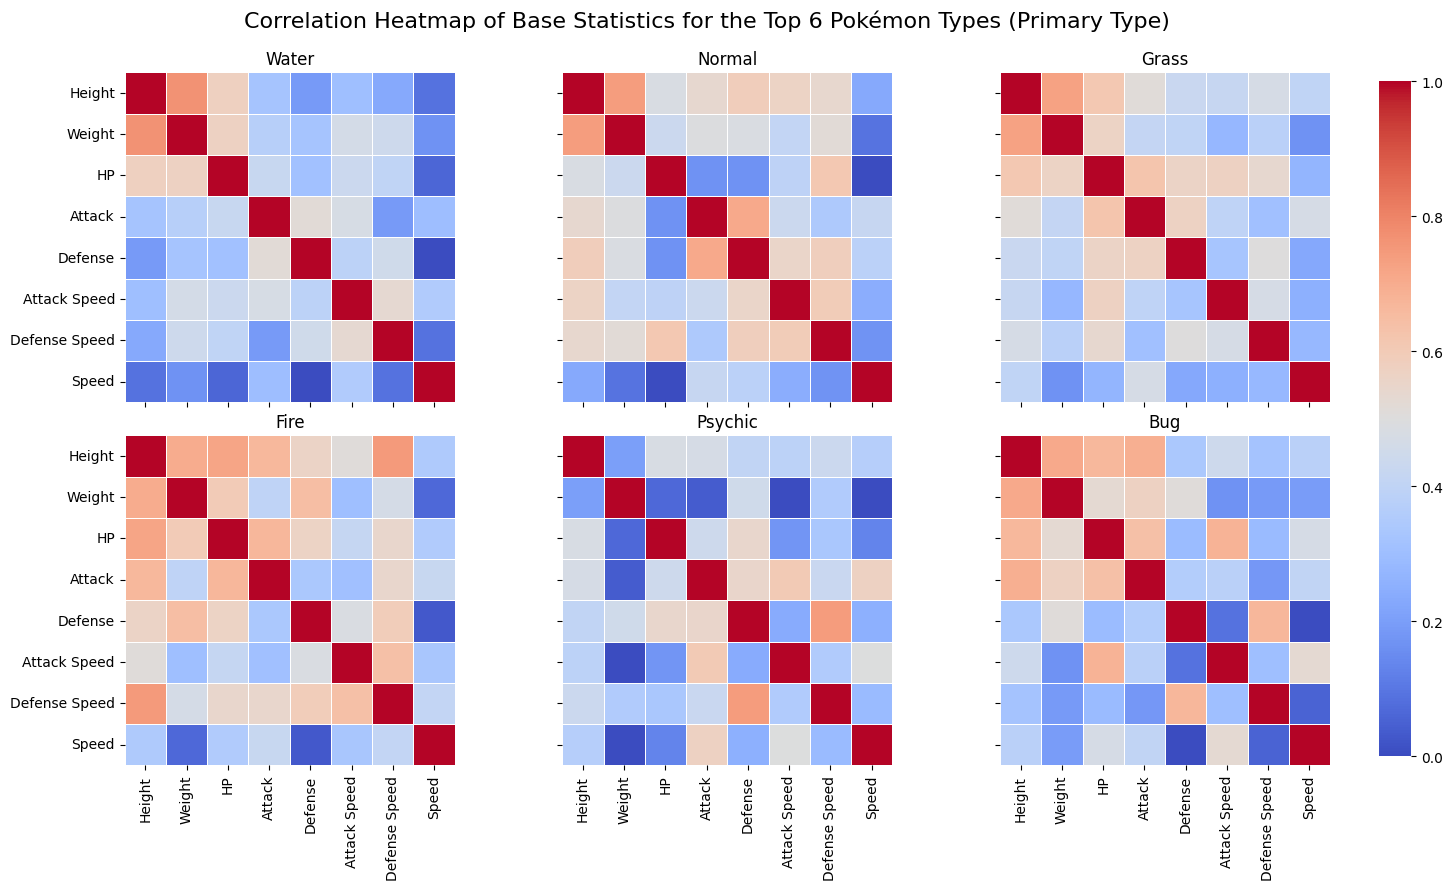

In [3]:
fig, axs=plt.subplots(2,3,sharex=True, sharey=True, figsize=(16,9))

#..Initializing a custom axes instance for the colorbar, explicitly positioned on the right side of the figure layout
cbar_ax = fig.add_axes([0.92, 0.12, 0.02, 0.75])

heatmap_args = {
    'cmap': 'coolwarm',
    'vmin': 0, 'vmax': 1,  #..Values to anchor colormap
    'cbar': True,
    'cbar_ax': cbar_ax,
    'square': True, 
    'linewidths': .5 
}

#..Water
sns.heatmap(daneg.get_group('Water')[stats01].corr(),ax=axs[0,0],**heatmap_args)
axs[0,0].set_title('Water')
#..Normal
sns.heatmap(daneg.get_group('Normal')[stats01].corr(),ax=axs[0,1],**heatmap_args)
axs[0,1].set_title('Normal')
#..Grass
sns.heatmap(daneg.get_group('Grass')[stats01].corr(),ax=axs[0,2],**heatmap_args)
axs[0,2].set_title('Grass') 
#..Flying
sns.heatmap(daneg.get_group('Fire')[stats01].corr(),ax=axs[1,0],**heatmap_args)
axs[1,0].set_title('Fire')
#..Psychic
sns.heatmap(daneg.get_group('Psychic')[stats01].corr(),ax=axs[1,1],**heatmap_args)
axs[1,1].set_title('Psychic') 
#..Bug
sns.heatmap(daneg.get_group('Bug')[stats01].corr(),ax=axs[1,2],**heatmap_args)
axs[1,2].set_title('Bug')

fig.subplots_adjust(
    right=0.9, #..Limits the subplots to 90% of the figure width, leaving the remaining 10% empty to accommodate the custom colorbar
    hspace=0.1, wspace=0.2 #..Defines the whitespace between rows and columns, h -> between rows, w -> between columns
    )
plt.suptitle('Correlation Heatmap of Base Statistics for the Top 6 Pokémon Types (Primary Type)',y=0.95,fontsize=16)

#..bbox_inches='tight' adjust the size of figure, so that the labels are not cut
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()